# House Pricing Dataset

## Libraries

###EDA

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for mode value
from statistics import  mode
# Scaling numerical data
from sklearn.preprocessing import MinMaxScaler,StandardScaler
# Scaling categorical data
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
# for train test-split
from sklearn.model_selection import train_test_split

## Read Dataset

In [20]:
filepath = '/content/House_Pricing.csv'
df_house_price = pd.read_csv(filepath)
df_house_price.head(2)


,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639


## Preprocessing

In [21]:
df_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [22]:
df_house_price.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Duplication Removal

In [23]:
df_house_price.duplicated().sum()      # to find the duplicate rows

np.int64(0)

In [24]:
df_house_price.T.duplicated().sum()   # to find the duplicate columns

np.int64(0)

## Correlation Analysis

In [25]:
numeric_df = df_house_price.select_dtypes(include=np.number)
corr_mat = numeric_df.corr()
corr_mat

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
ID,1.000000,-0.016834,0.001286,0.005186,-0.012384,-0.132110,0.018525,0.013799,-0.010738,-0.005151,-0.021380,-0.016907,-0.008269,-0.001952,0.020805,-0.002888,-0.138798
Sale Price,-0.016834,1.000000,0.308463,0.525124,0.702081,0.089616,0.256941,0.580654,0.605495,0.323813,-0.054034,0.126436,-0.053198,0.306889,0.021507,0.585393,0.082445
No of Bedrooms,0.001286,0.308463,1.000000,0.515883,0.576616,0.031620,0.175429,0.349008,0.477592,0.303093,-0.154178,0.018841,-0.152656,-0.008879,0.129499,0.391649,0.029244
No of Bathrooms,0.005186,0.525124,0.515883,1.000000,0.754691,0.087758,0.500601,0.635573,0.685249,0.283774,-0.505957,0.050752,-0.204044,0.024508,0.223165,0.568606,0.087218
Flat Area (in Sqft),-0.012384,0.702081,0.576616,0.754691,1.000000,0.172809,0.353950,0.705835,0.876587,0.435230,-0.318207,0.055365,-0.199416,0.052543,0.240152,0.756357,0.183223
Lot Area (in Sqft),-0.132110,0.089616,0.031620,0.087758,0.172809,1.000000,-0.005235,0.102345,0.183512,0.015287,-0.053062,0.007717,-0.129536,-0.085672,0.229494,0.144548,0.718548
No of Floors,0.018525,0.256941,0.175429,0.500601,0.353950,-0.005235,1.000000,0.461228,0.523840,-0.245705,-0.489319,0.006338,-0.059122,0.049648,0.125391,0.279874,-0.011269
Overall Grade,0.013799,0.580654,0.349008,0.635573,0.705835,0.102345,0.461228,1.000000,0.705183,0.145266,-0.456629,0.010440,-0.185836,0.111301,0.201745,0.681338,0.107581
Area of the House from Basement (in Sqft),-0.010738,0.605495,0.477592,0.685249,0.876587,0.183512,0.523840,0.705183,1.000000,-0.051821,-0.423822,0.023301,-0.261130,-0.000866,0.343776,0.731998,0.194100
Basement Area (in Sqft),-0.005151,0.323813,0.303093,0.283774,0.435230,0.015287,-0.245705,0.145266,-0.051821,1.000000,0.133124,0.071323,0.074854,0.110554,-0.144728,0.200371,0.017276


### Plotting Heatmap

Text(0.5, 1.0, 'Correlation heatmap')

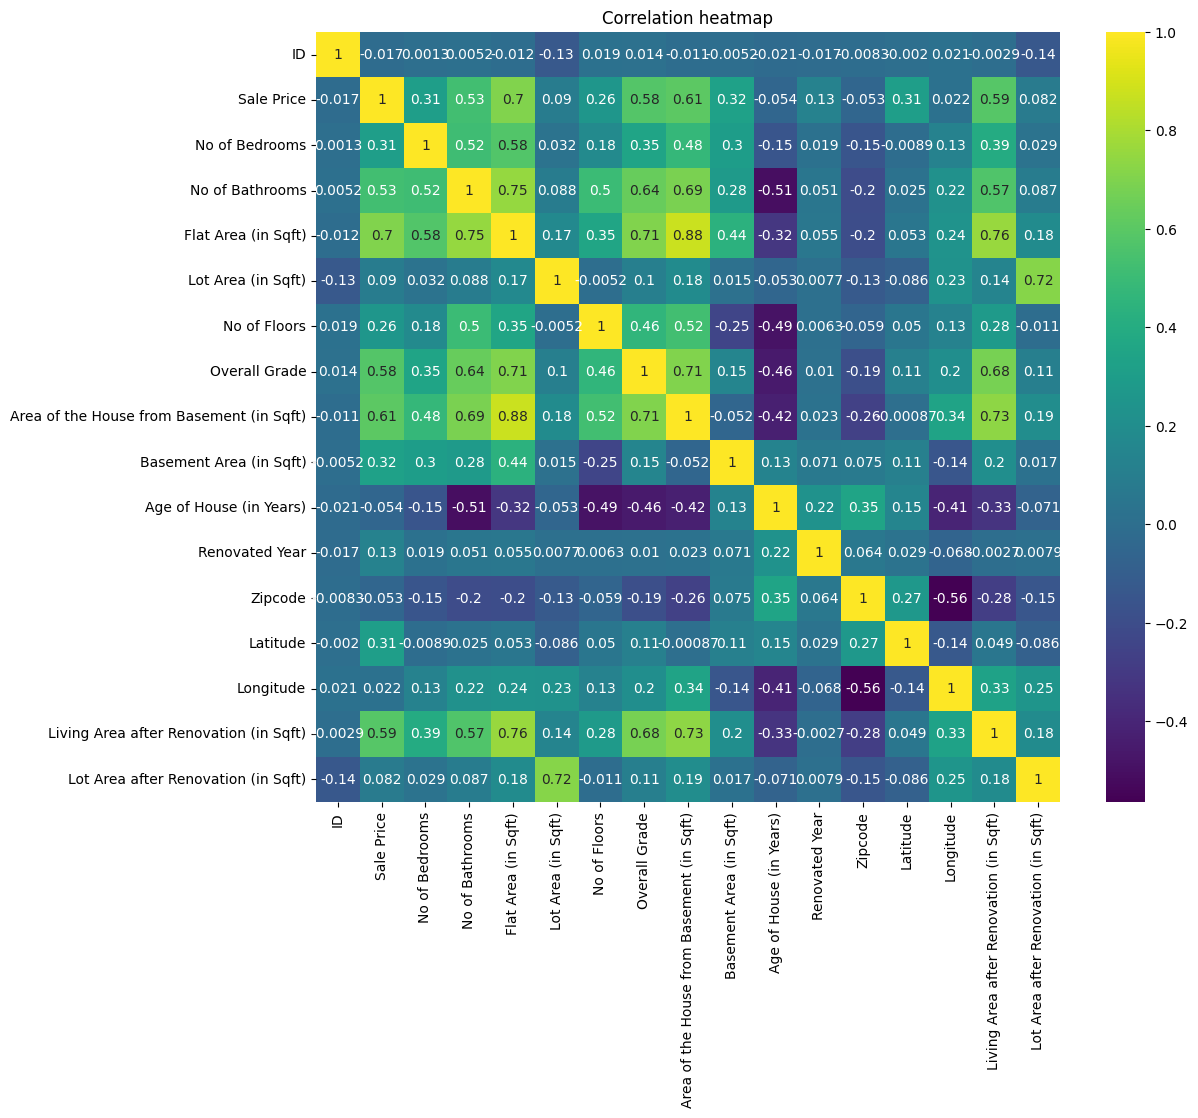

In [26]:
plt.figure(figsize =(12,10))
sns.heatmap(corr_mat,annot = True,cmap = 'viridis',fmt = '.2g')
plt.title('Correlation heatmap')

## Handling Missing Values

In [27]:
df_house_price.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


### dropped the null value rows from the target ' Sale Price '

In [28]:
df_house_price = df_house_price.dropna(subset = ['Sale Price'])
df_house_price.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19485


## Plotting of null value columns

<Axes: xlabel='No of Bathrooms', ylabel='Density'>

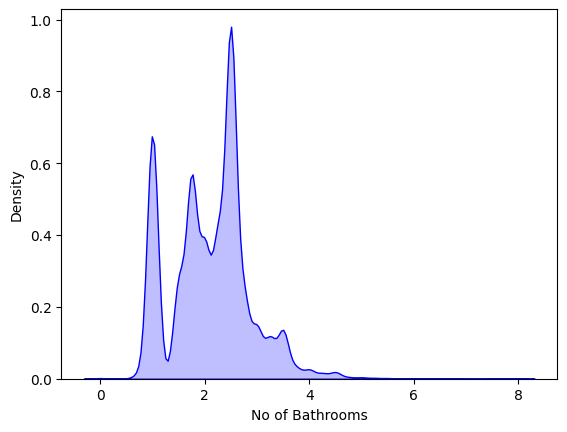

In [29]:
sns.kdeplot(df_house_price['No of Bathrooms'], fill = True, color= 'b')

### dropping of null values


In [30]:
df_house_price['No of Bathrooms'].fillna(df_house_price['No of Bathrooms'].median(),inplace = True)

/tmp/ipykernel_5710/1112805932.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['No of Bathrooms'].fillna(df_house_price['No of Bathrooms'].median(),inplace = True)


<Axes: xlabel='Flat Area (in Sqft)', ylabel='Density'>

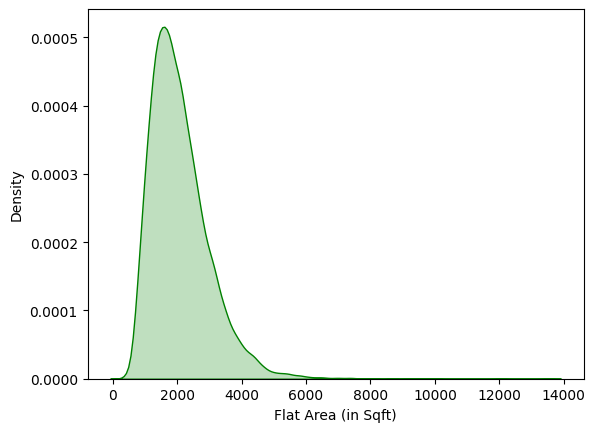

In [31]:
sns.kdeplot(df_house_price['Flat Area (in Sqft)'], fill = True, color= 'g')

In [32]:
df_house_price['Flat Area (in Sqft)'].fillna(df_house_price['Flat Area (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_5710/1440046811.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Flat Area (in Sqft)'].fillna(df_house_price['Flat Area (in Sqft)'].median(),inplace = True)


<Axes: xlabel='Lot Area (in Sqft)', ylabel='Density'>

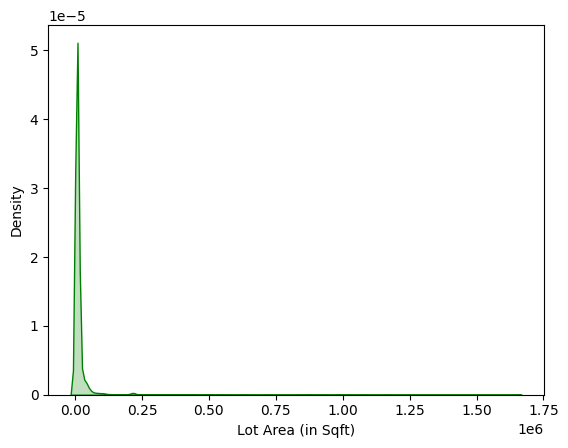

In [33]:
sns.kdeplot(df_house_price['Lot Area (in Sqft)'], fill = True, color= 'g')

In [34]:
df_house_price['Lot Area (in Sqft)'].fillna(df_house_price['Lot Area (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_5710/275597162.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Lot Area (in Sqft)'].fillna(df_house_price['Lot Area (in Sqft)'].median(),inplace = True)


<Axes: xlabel='Area of the House from Basement (in Sqft)', ylabel='Density'>

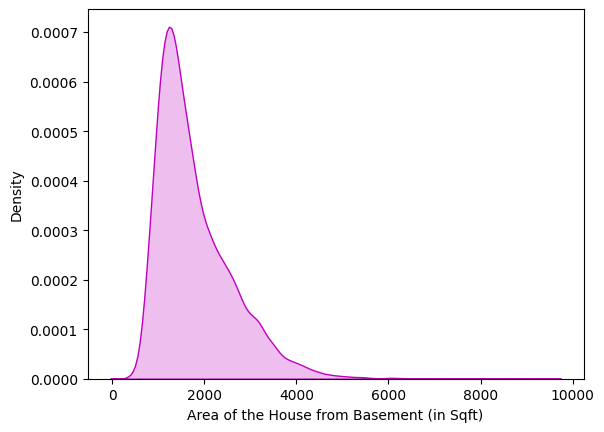

In [35]:
sns.kdeplot(df_house_price['Area of the House from Basement (in Sqft)'], fill = True, color= 'm')

In [36]:
df_house_price['Area of the House from Basement (in Sqft)'].fillna(df_house_price['Area of the House from Basement (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_5710/1780526693.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Area of the House from Basement (in Sqft)'].fillna(df_house_price['Area of the House from Basement (in Sqft)'].median(),inplace = True)


<Axes: xlabel='Area of the House from Basement (in Sqft)', ylabel='Density'>

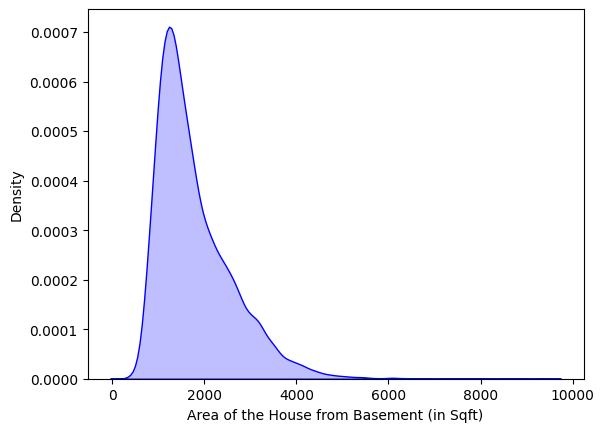

In [37]:
sns.kdeplot(df_house_price['Area of the House from Basement (in Sqft)'], fill = True, color= 'b')

<Axes: xlabel='Zipcode', ylabel='Density'>

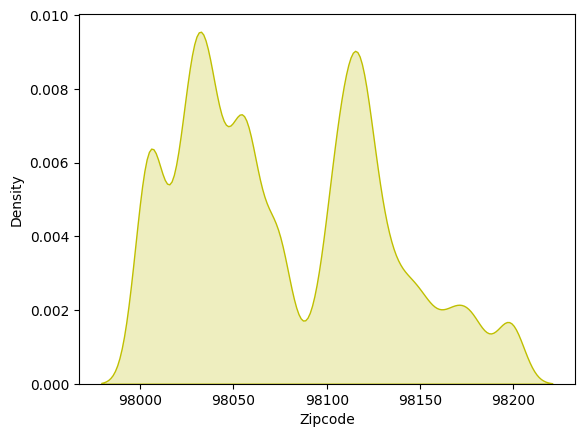

In [38]:
sns.kdeplot(df_house_price['Zipcode'], fill = True, color= 'y')

In [39]:
df_house_price['Zipcode'].fillna(mode(df_house_price['Zipcode']),inplace = True)

/tmp/ipykernel_5710/3476169193.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Zipcode'].fillna(mode(df_house_price['Zipcode']),inplace = True)


<Axes: xlabel='Latitude', ylabel='Density'>

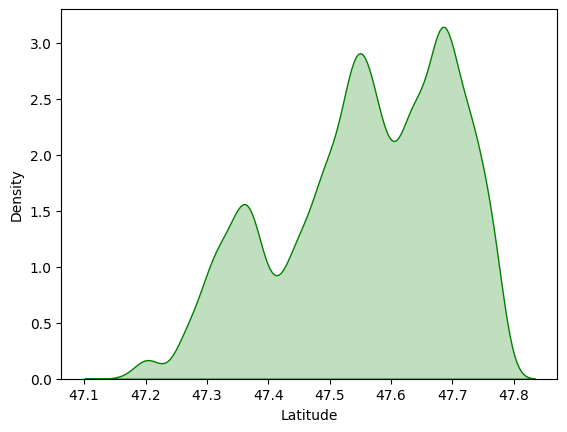

In [40]:
sns.kdeplot(df_house_price['Latitude'], fill = True, color= 'g')

In [41]:
df_house_price['Latitude'].fillna(df_house_price['Latitude'].median(),inplace = True)

/tmp/ipykernel_5710/1302670502.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Latitude'].fillna(df_house_price['Latitude'].median(),inplace = True)


<Axes: xlabel='Longitude', ylabel='Density'>

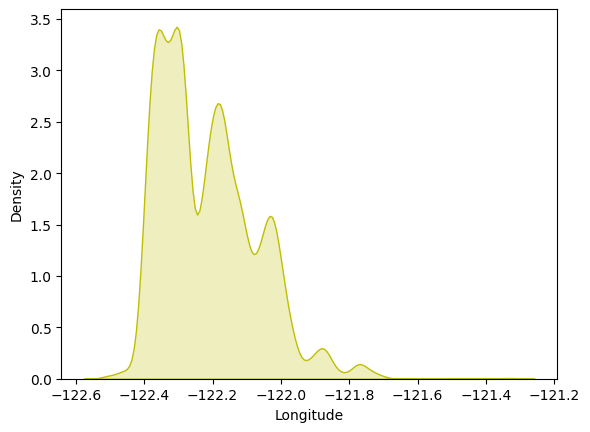

In [42]:
sns.kdeplot(df_house_price['Longitude'], fill = True, color= 'y')

In [43]:
df_house_price['Longitude'].fillna(df_house_price['Longitude'].median(),inplace = True)

/tmp/ipykernel_5710/562953108.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Longitude'].fillna(df_house_price['Longitude'].median(),inplace = True)


<Axes: xlabel='Living Area after Renovation (in Sqft)', ylabel='Density'>

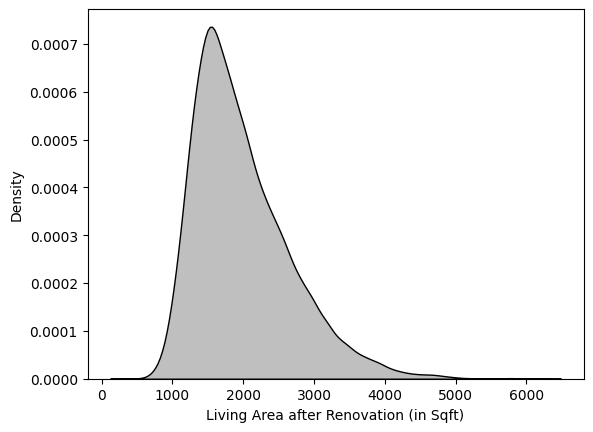

In [44]:
sns.kdeplot(df_house_price['Living Area after Renovation (in Sqft)'], fill = True, color= 'k')

In [45]:
df_house_price['Living Area after Renovation (in Sqft)'].fillna(df_house_price['Living Area after Renovation (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_5710/306017078.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house_price['Living Area after Renovation (in Sqft)'].fillna(df_house_price['Living Area after Renovation (in Sqft)'].median(),inplace = True)


In [46]:
# droped 'No of Times Visited'
df_house_price.drop(columns = ['No of Times Visited'],inplace = True)
df_house_price.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


In [47]:
# Fetching numerical columns

num_cols = df_house_price.select_dtypes(include = ['int64','float64']).columns
print(num_cols)

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


In [48]:
# fetching categorical columns

cat_cols = df_house_price.select_dtypes(include = ['object']).columns
print(cat_cols)

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')


In [49]:
symmetric_cols = ['ID', 'Overall Grade', 'Age of House (in Years)','Zipcode','Latitude']        #used for standard scaling
skewed_cols = ['No of Bathrooms','No of Bedrooms','Flat Area (in Sqft)','Lot Area (in Sqft)','Area of the House from Basement (in Sqft)','Longitude','Living Area after Renovation (in Sqft)','Lot Area after Renovation (in Sqft)']  # used for min max scaling

In [50]:

# Find skewness of all numeric columns
skew_values = df_house_price.skew(numeric_only=True)

print(skew_values)

ID                                            0.243092
Sale Price                                    4.021472
No of Bedrooms                                1.974912
No of Bathrooms                               0.511335
Flat Area (in Sqft)                           1.472391
Lot Area (in Sqft)                           13.059616
No of Floors                                  0.616039
Overall Grade                                 0.321409
Area of the House from Basement (in Sqft)     1.446943
Basement Area (in Sqft)                       1.578058
Age of House (in Years)                       0.469648
Renovated Year                                4.549013
Zipcode                                       0.405699
Latitude                                     -0.485150
Longitude                                     0.884822
Living Area after Renovation (in Sqft)        1.108228
Lot Area after Renovation (in Sqft)           9.505931
dtype: float64


In [51]:
symmetric_columns = skew_values[abs(skew_values) < 0.5].index.tolist()

print("Symmetric columns:", symmetric_columns)

Symmetric columns: ['ID', 'Overall Grade', 'Age of House (in Years)', 'Zipcode', 'Latitude']


In [52]:
# before scaling
df_house_price.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [53]:
# object for standard scaling
std_scaler = StandardScaler()
df_house_price[symmetric_cols] = std_scaler.fit_transform(df_house_price[symmetric_cols])
#after scaling
df_house_price.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.885986,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,-0.563993,1180.0,0,0.544734,0,1.870094,-0.352576,-122.257,1340.0,5650
1,0.637358,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,-0.563993,2170.0,400,0.680915,1991,0.879534,1.161645,-122.319,1690.0,7639
2,0.365299,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,-1.468566,770.0,0,1.293731,0,-0.933379,1.283619,-122.233,2720.0,8062
3,-0.727767,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,-0.563993,1050.0,910,0.204281,0,1.085122,-0.283288,-122.393,1360.0,5000
4,-0.912987,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,0.340581,1680.0,0,-0.544715,0,-0.073647,0.409587,-122.045,1800.0,7503


In [54]:
# object for min_max scaling
min_max_scaler = MinMaxScaler()
df_house_price[skewed_cols] = min_max_scaler.fit_transform(df_house_price[skewed_cols])
# after Scaling
df_house_price.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.885986,14 October 2017,221900.0,0.090909,0.12500,0.067170,0.003108,1.0,No,Fair,-0.563993,0.097588,0,0.544734,0,1.870094,-0.352576,0.217608,0.161934,0.005742
1,0.637358,14 December 2017,538000.0,0.090909,0.28125,0.172075,0.004072,2.0,No,Fair,-0.563993,0.206140,400,0.680915,1991,0.879534,1.161645,0.166113,0.222165,0.008027
2,0.365299,15 February 2016,180000.0,0.060606,0.12500,0.036226,0.005743,1.0,No,Fair,-1.468566,0.052632,0,1.293731,0,-0.933379,1.283619,0.237542,0.399415,0.008513
3,-0.727767,14 December 2017,604000.0,0.121212,0.37500,0.126038,0.002714,1.0,No,Excellent,-0.563993,0.083333,910,0.204281,0,1.085122,-0.283288,0.104651,0.165376,0.004996
4,-0.912987,15 February 2016,510000.0,0.090909,0.25000,0.104906,0.004579,1.0,No,Fair,0.340581,0.152412,0,-0.544715,0,-0.073647,0.409587,0.393688,0.241094,0.007871


In [55]:
df_house_price.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.160900e+04,2.160900e+04,21609.000000,21609.000000,21609.000000,21609.000000,21609.000000,2.160900e+04,21609.000000,21609.000000,2.160900e+04,21609.000000,2.160900e+04,2.160900e+04,21609.000000,21609.000000,21609.000000
mean,8.746558e-17,5.401984e+05,0.102145,0.264339,0.135085,0.008836,1.494215,2.157046e-16,0.164289,291.513490,-1.473104e-16,84.417881,6.548344e-14,-1.593156e-14,0.253426,0.273198,0.013921
std,1.000023e+00,3.673890e+05,0.028179,0.096262,0.069309,0.025092,0.539909,1.000023e+00,0.090787,442.570991,1.000023e+00,401.714775,1.000023e+00,1.000023e+00,0.116970,0.117953,0.031367
min,-1.592056e+00,7.500000e+04,0.000000,0.000000,0.000000,0.000000,1.000000,-5.991431e+00,0.000000,0.000000,-1.497983e+00,0.000000,-1.438004e+00,-2.916935e+00,0.000000,0.000000,0.000000
25%,-8.543587e-01,3.219500e+05,0.090909,0.218750,0.086038,0.002738,1.000000,-5.639925e-01,0.098684,0.000000,-8.851681e-01,0.000000,-8.399296e-01,-6.427171e-01,0.158638,0.187747,0.005111
50%,-2.349156e-01,4.500000e+05,0.090909,0.281250,0.122264,0.004300,1.500000,-5.639925e-01,0.139254,0.000000,-1.361717e-01,0.000000,-2.418554e-01,8.480154e-02,0.240033,0.247978,0.008005
75%,9.484209e-01,6.450000e+05,0.121212,0.312500,0.170566,0.006159,2.000000,3.405806e-01,0.210526,560.000000,6.809153e-01,0.000000,7.487050e-01,8.512944e-01,0.327243,0.337463,0.010836
max,1.849176e+00,7.700000e+06,1.000000,1.000000,1.000000,1.000000,3.500000,2.149727e+00,1.000000,4820.000000,2.417225e+00,2015.000000,2.262580e+00,1.570152e+00,1.000000,1.000000,1.000000


##Outlier Dettection

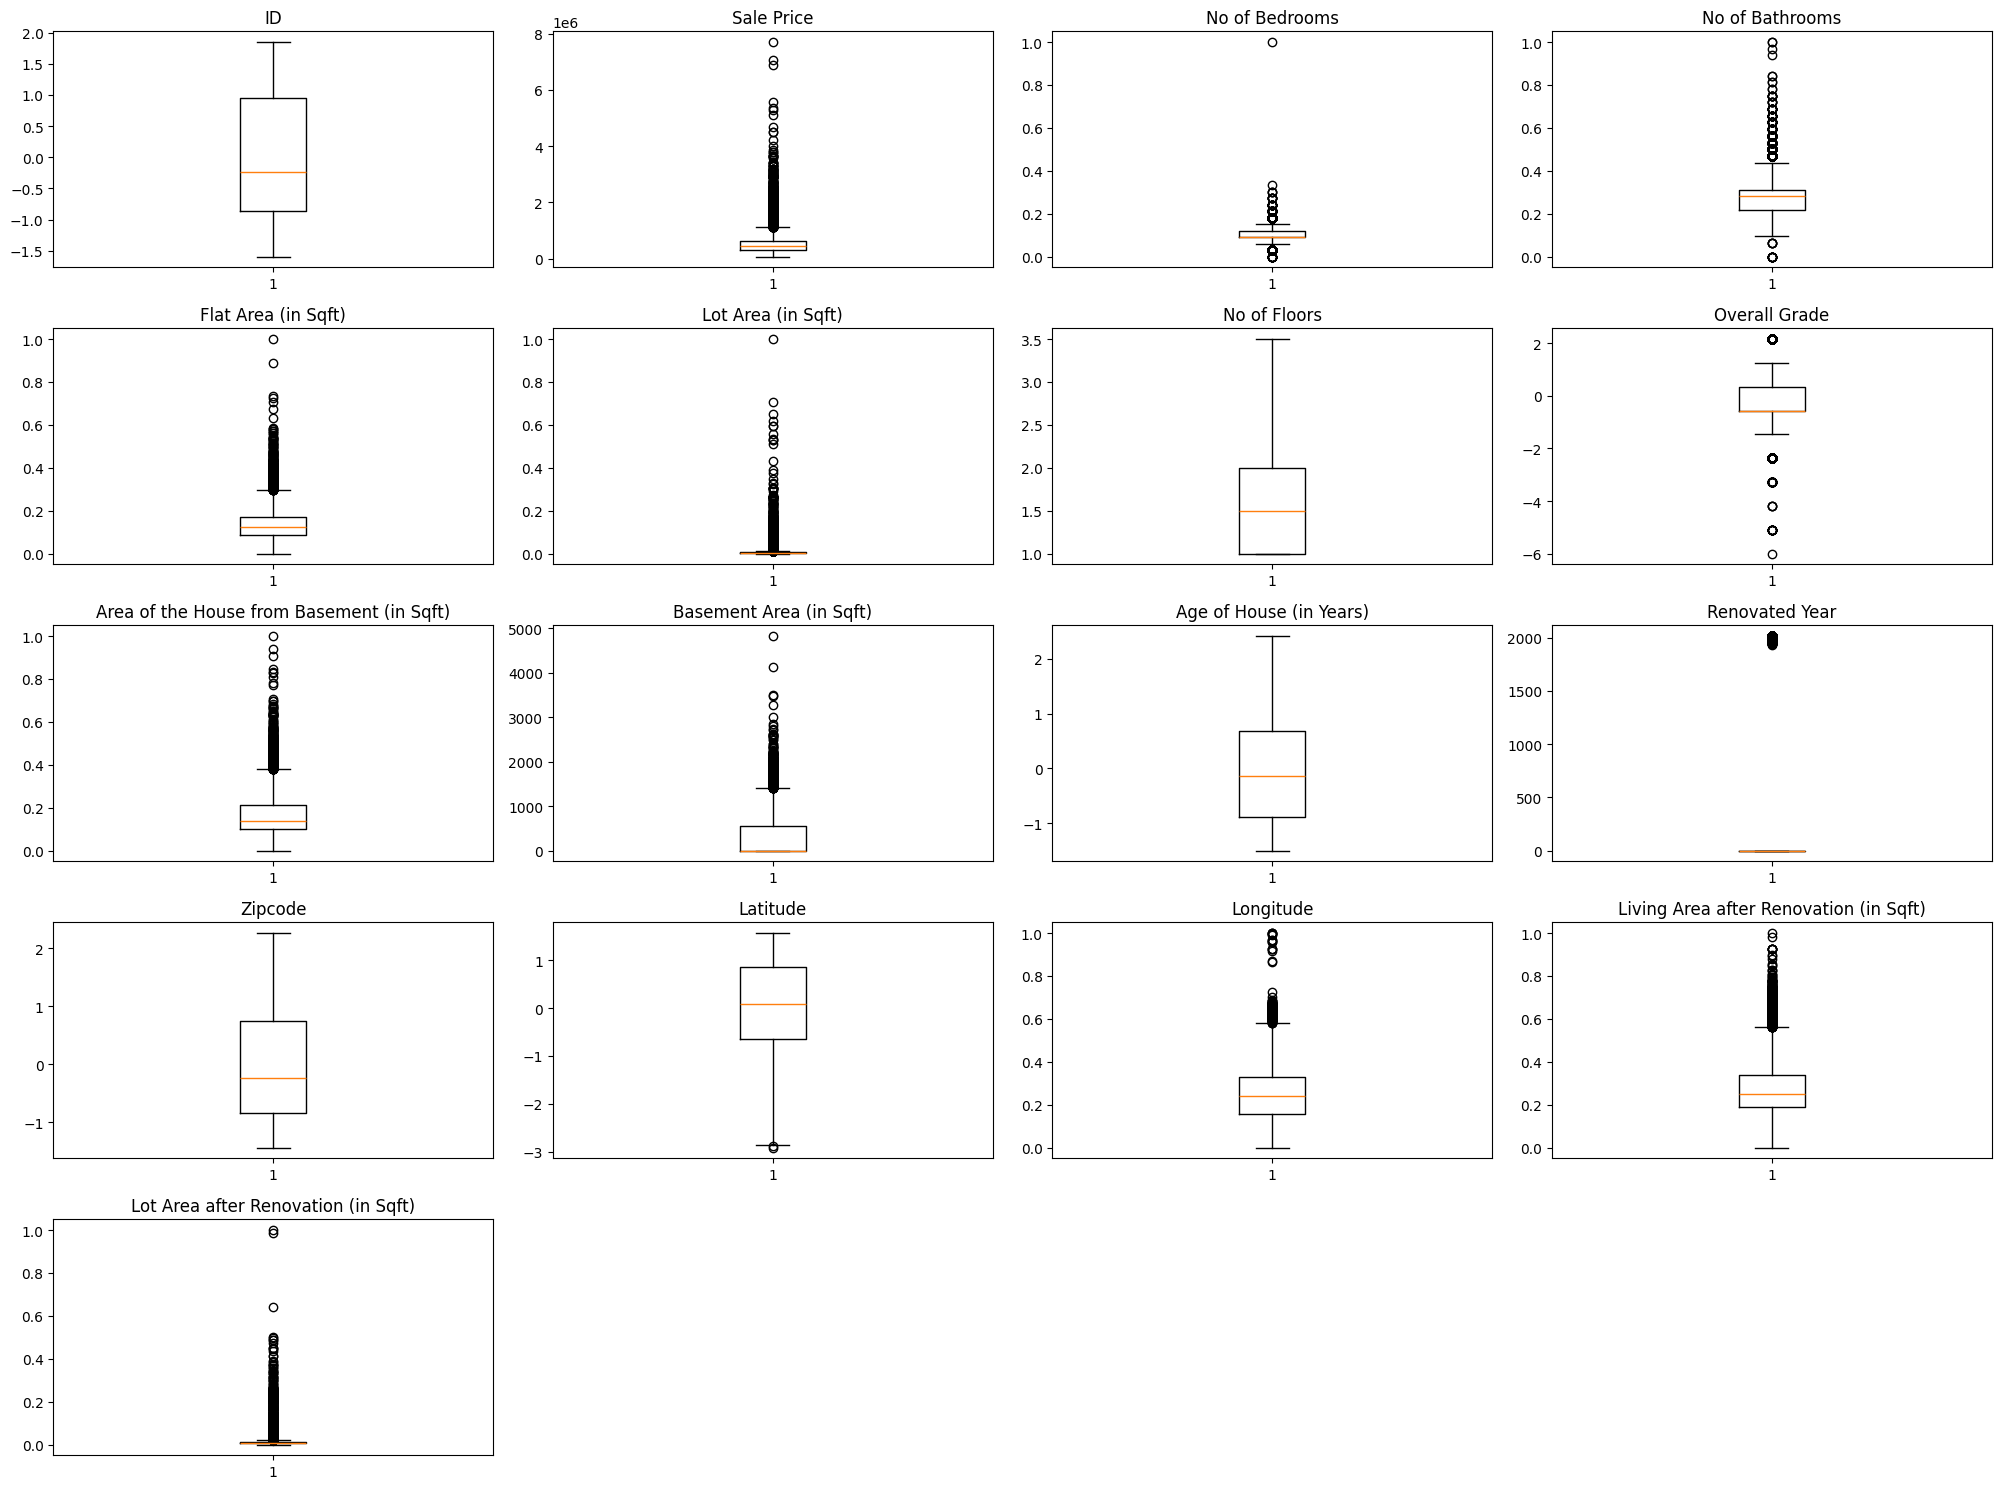

In [56]:
cols = df_house_price.select_dtypes(include='number').columns[:20]

plt.figure(figsize=(20, 15))

i = 1
for col in cols:
    plt.subplot(5, 4, i)
    plt.boxplot(df_house_price[col].dropna())
    plt.title(col)
    i += 1

plt.tight_layout()
plt.show()

## Encoding

In [57]:
# listing all categorical columns
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')

In [58]:
# listing all numerical columns
num_cols

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [59]:
#fixing the target column
target = ['Sale Price']
feature_cat_cols = ['Date House was Sold','Waterfront View','Condition of the House']


In [60]:
df_house_price['Date House was Sold'].unique()

array(['14 October 2017', '14 December 2017', '15 February 2016',
       '14 May 2017', '14 June 2017', '15 January 2016', '15 April 2016',
       '15 March 2016', '14 July 2017', '14 August 2017',
       '14 November 2017', '14 September 2017', '15 May 2016'],
      dtype=object)

In [61]:
df_house_price['Waterfront View'].unique()

array(['No', 'Yes'], dtype=object)

In [62]:
df_house_price['Condition of the House'].unique()

array(['Fair', 'Excellent', 'Good', 'Bad', 'Okay'], dtype=object)

In [63]:
#object
label_encoder_obj = LabelEncoder()
# only target columns and binary features are to be transformed using label encoder
#using label encoder in this case,columns['Waterfront View']
df_house_price['Waterfront View'] = label_encoder_obj.fit_transform(df_house_price['Waterfront View'])



# after encoding
df_house_price.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.885986,14 October 2017,221900.0,0.090909,0.12500,0.067170,0.003108,1.0,0,Fair,-0.563993,0.097588,0,0.544734,0,1.870094,-0.352576,0.217608,0.161934,0.005742
1,0.637358,14 December 2017,538000.0,0.090909,0.28125,0.172075,0.004072,2.0,0,Fair,-0.563993,0.206140,400,0.680915,1991,0.879534,1.161645,0.166113,0.222165,0.008027
2,0.365299,15 February 2016,180000.0,0.060606,0.12500,0.036226,0.005743,1.0,0,Fair,-1.468566,0.052632,0,1.293731,0,-0.933379,1.283619,0.237542,0.399415,0.008513
3,-0.727767,14 December 2017,604000.0,0.121212,0.37500,0.126038,0.002714,1.0,0,Excellent,-0.563993,0.083333,910,0.204281,0,1.085122,-0.283288,0.104651,0.165376,0.004996
4,-0.912987,15 February 2016,510000.0,0.090909,0.25000,0.104906,0.004579,1.0,0,Fair,0.340581,0.152412,0,-0.544715,0,-0.073647,0.409587,0.393688,0.241094,0.007871


In [98]:
# One hot encoding

ohe_cols = ['Condition of the House','Date House was Sold']
df_ohe_1 =pd.get_dummies(df_house_price,columns = ohe_cols,drop_first=True,dtype = int)
df_ohe_1.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Area of the House from Basement (in Sqft),...,Date House was Sold_14 June 2017,Date House was Sold_14 May 2017,Date House was Sold_14 November 2017,Date House was Sold_14 October 2017,Date House was Sold_14 September 2017,Date House was Sold_15 April 2016,Date House was Sold_15 February 2016,Date House was Sold_15 January 2016,Date House was Sold_15 March 2016,Date House was Sold_15 May 2016
0,0.885986,221900.0,0.090909,0.12500,0.067170,0.003108,1.0,0,-0.563993,0.097588,...,0,0,0,1,0,0,0,0,0,0
1,0.637358,538000.0,0.090909,0.28125,0.172075,0.004072,2.0,0,-0.563993,0.206140,...,0,0,0,0,0,0,0,0,0,0
2,0.365299,180000.0,0.060606,0.12500,0.036226,0.005743,1.0,0,-1.468566,0.052632,...,0,0,0,0,0,0,1,0,0,0
3,-0.727767,604000.0,0.121212,0.37500,0.126038,0.002714,1.0,0,-0.563993,0.083333,...,0,0,0,0,0,0,0,0,0,0
4,-0.912987,510000.0,0.090909,0.25000,0.104906,0.004579,1.0,0,0.340581,0.152412,...,0,0,0,0,0,0,1,0,0,0


In [97]:
df_ohe_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21609 entries, 0 to 21612
Data columns (total 34 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21609 non-null  float64
 1   Sale Price                                 21609 non-null  float64
 2   No of Bedrooms                             21609 non-null  float64
 3   No of Bathrooms                            21609 non-null  float64
 4   Flat Area (in Sqft)                        21609 non-null  float64
 5   Lot Area (in Sqft)                         21609 non-null  float64
 6   No of Floors                               21609 non-null  float64
 7   Waterfront View                            21609 non-null  int64  
 8   Overall Grade                              21609 non-null  float64
 9   Area of the House from Basement (in Sqft)  21609 non-null  float64
 10  Basement Area (in Sqft)    

## Outlier

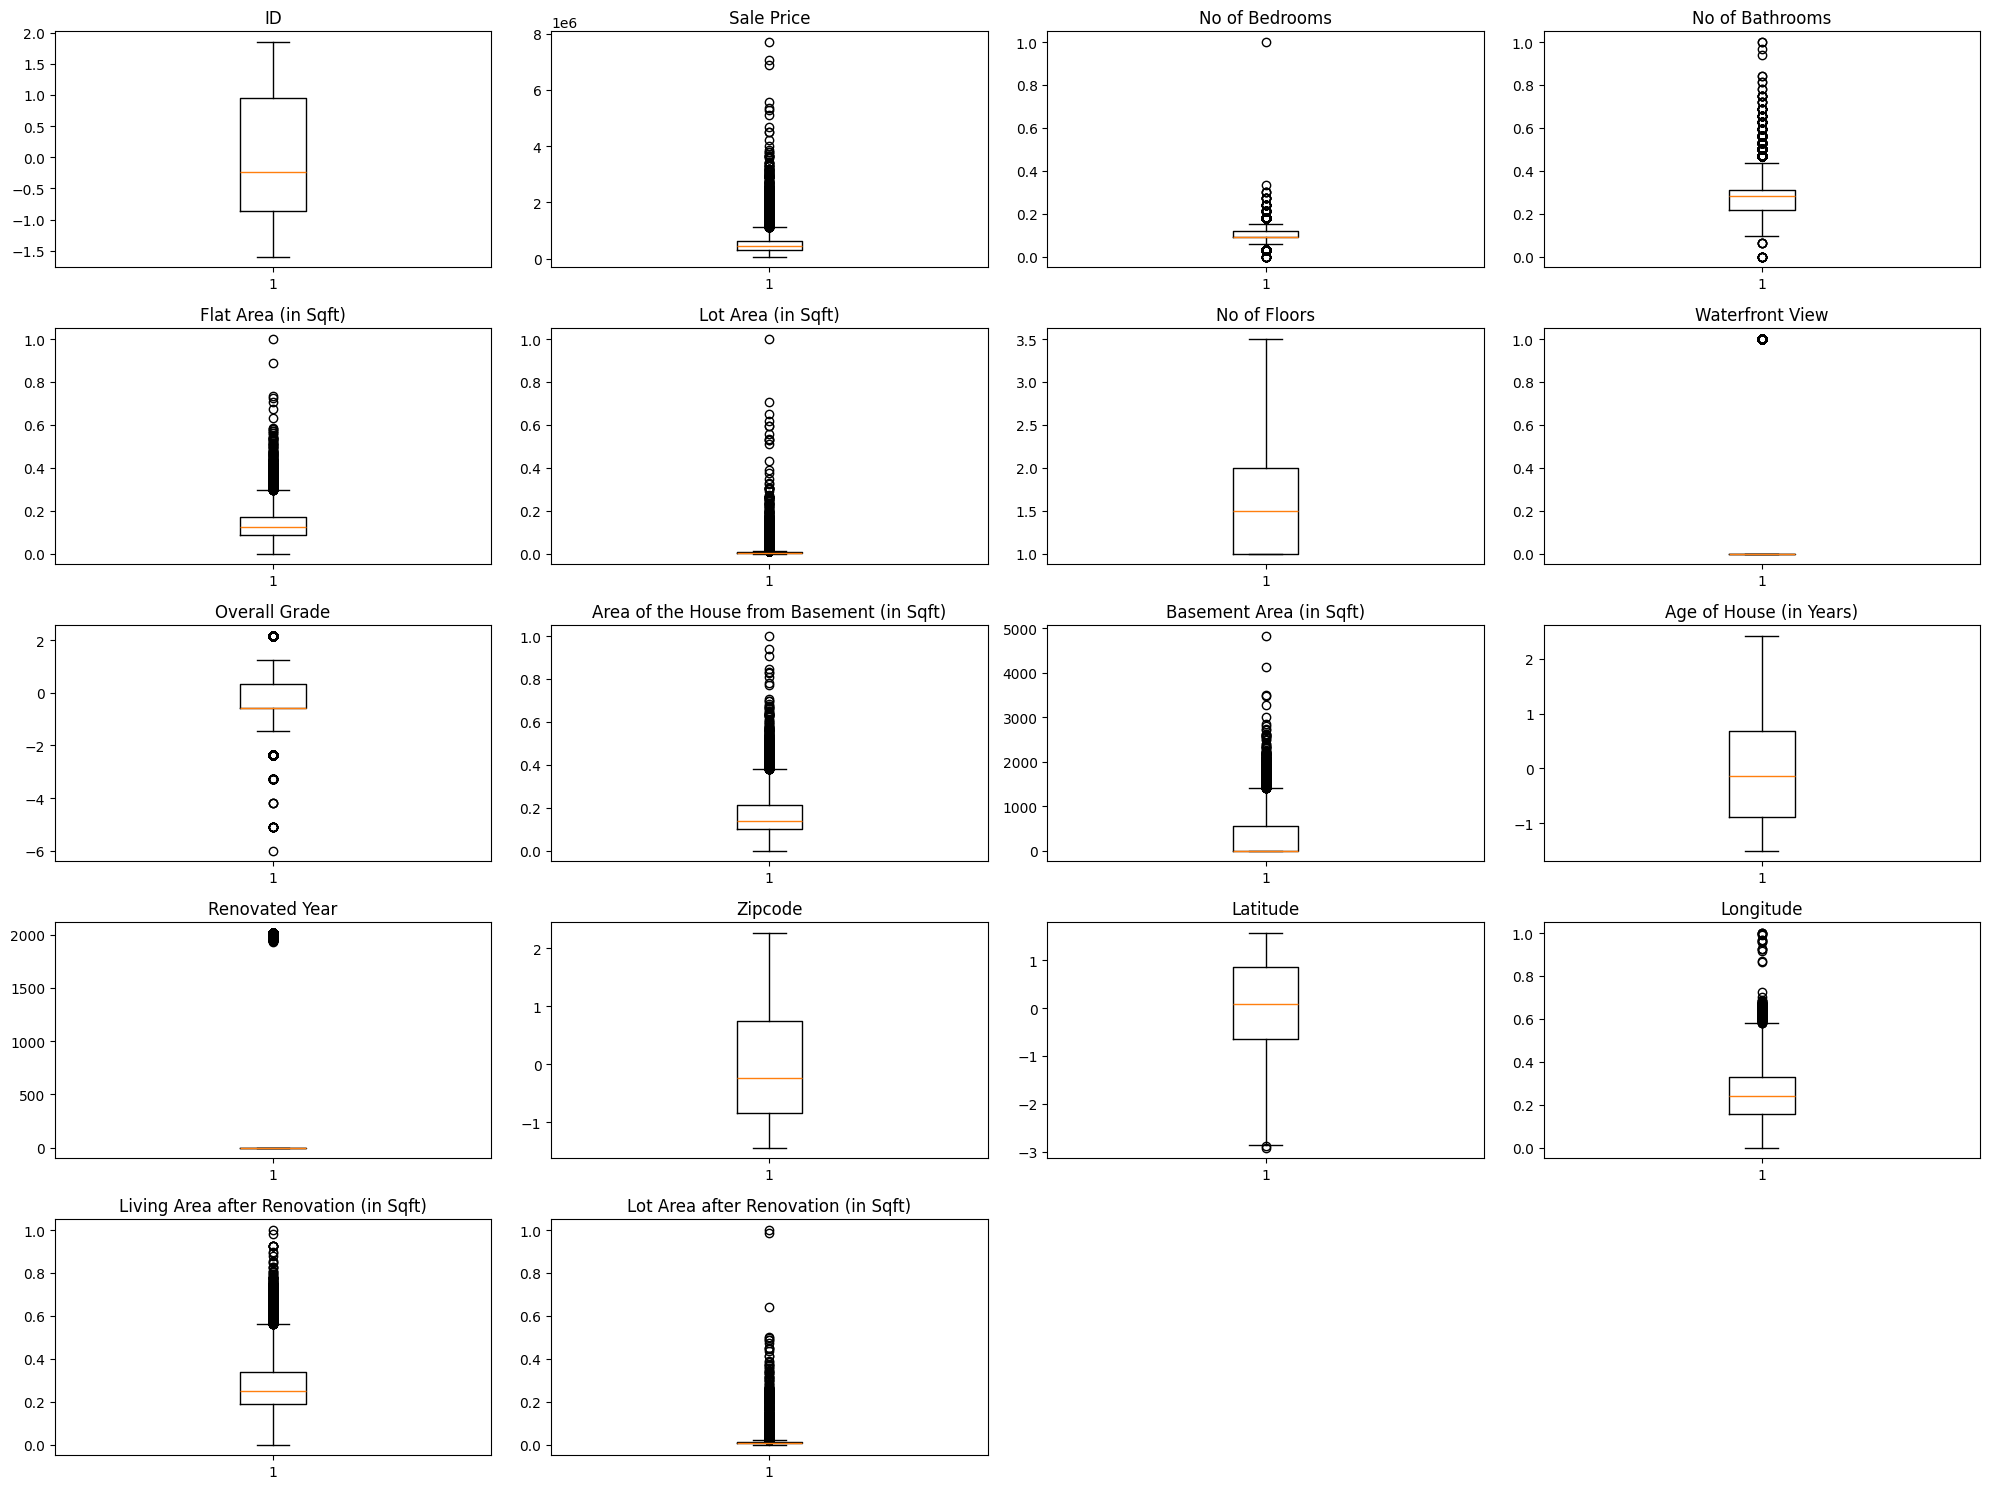

In [65]:
cols = df_house_price.select_dtypes(include='number').columns[:20]

plt.figure(figsize=(20, 15))

i = 1
for col in cols:
    plt.subplot(5, 4, i)
    plt.boxplot(df_house_price[col].dropna())
    plt.title(col)
    i += 1

plt.tight_layout()
plt.show()

In [66]:
# Find outlier
Q1 = df_house_price['No of Bedrooms'].quantile(0.25)
Q3 = df_house_price['No of Bedrooms'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [67]:
outliers_bedrooms = df_house_price[(df_house_price['No of Bedrooms']< lower_bound) | (df_house_price['No of Bedrooms']> upper_bound)]
len(outliers_bedrooms)

545

In [68]:
outliers_bedrooms['No of Bedrooms']


,No of Bedrooms
154,0.030303
209,0.181818
232,0.181818
239,0.181818
264,0.030303
...,...
21332,0.030303
21375,0.181818
21443,0.030303
21519,0.030303


In [69]:
filtered_data = df_house_price[(df_house_price['No of Bedrooms']> lower_bound) & (df_house_price['No of Bedrooms']< upper_bound)]
len(filtered_data)

21064

In [70]:
df_house_price['No of Bedrooms'] = df_house_price['No of Bedrooms'].clip(lower_bound,upper_bound)
df_house_price.shape

(21609, 20)

In [71]:
Q1 = df_house_price['No of Bathrooms'].quantile(0.25)
Q3 = df_house_price['No of Bathrooms'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [72]:
outliers_bathrooms = df_house_price[(df_house_price['No of Bathrooms']< lower_bound) | (df_house_price['No of Bathrooms']> upper_bound)]
len(outliers_bathrooms)

571

In [73]:
filtered_data = df_house_price[(df_house_price['No of Bathrooms']> lower_bound) & (df_house_price['No of Bathrooms']< upper_bound)]
len(filtered_data)
df_house_price['No of Bathrooms'] = df_house_price['No of Bathrooms'].clip(lower_bound,upper_bound)
df_house_price.shape

(21609, 20)

In [74]:
#  OR

In [75]:
# Fetching columns that need outlier removal
outlier_cols = [
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Basement Area (in Sqft)',
    'Living Area after Renovation (in Sqft)',
    'Lot Area after Renovation (in Sqft)'
]

for col in outlier_cols:

    Q1 = df_house_price[col].quantile(0.25) # first quartile
    Q3 = df_house_price[col].quantile(0.75) # third quartile

    IQR = Q3 - Q1                            # calculation of inter quartile range

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_house_price[(df_house_price[col] < lower_bound) | (df_house_price[col] > upper_bound)]    # values less than lowerbound or values greater than upper bound is called outliers

    print(f"{col}: {len(outliers)} outliers")

    df_house_price[col] = df_house_price[col].clip(lower=lower_bound, upper=upper_bound) # clipping of outliers
    df_house_price

Flat Area (in Sqft): 572 outliers
Lot Area (in Sqft): 2423 outliers
Area of the House from Basement (in Sqft): 610 outliers
Basement Area (in Sqft): 496 outliers
Living Area after Renovation (in Sqft): 544 outliers
Lot Area after Renovation (in Sqft): 2193 outliers


## Train-Test split

In [79]:
# Target variable
y = df_house_price['Sale Price']

# Features
X = df_house_price.drop('Sale Price', axis=1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(   X,
    y,
    test_size=0.2,
    random_state=42
)


# Check the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (17287, 19)
X_test : (4322, 19)
y_train: (17287,)
y_test : (4322,)
